# Mumbai Rent Radar — what should this flat actually cost?

**Decision owner:** a rental-listing pricing/QA team
**City:** Mumbai · **Data:** 5,100 listing rows (`Rental_Data.xlsx`) joined to a
604-locality attribute table (`Attributes.csv`: metro access, tech-park proximity,
zone, distance to CBD, school/hospital/retail density, geocoded lat/long)

A tenant comparing two 2BHKs in the same locality can see asking rents 40%+ apart
with no way to tell how much of that is genuine (floor, furnishing, a metro line
opening nearby) versus noise or a data-entry format quirk. This notebook does four
things, in order: **audit** the raw data honestly, **clean** it with every decision
recorded, **explore** what actually moves rent, and **model** it — reporting error
in rupees, against a baseline a spreadsheet could already produce, so the number at
the end means something to a pricing team rather than just to a data scientist.


In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

RENT_FILE = 'Rental_Data.xlsx'
ATTR_FILE = 'Attributes.csv'

## 1. Load

Two files, meant to be joined:

- **`Rental_Data.xlsx`** — one row per listing (`Listing Id`, `BHK`, `Rent`, `Size`,
  `Floor`, `Area Type`, `Area Locality`, `City`, `Furnishing Status`,
  `Tenant Preferred`, `Bathroom`, `Point of Contact`).
- **`Attributes.csv`** — one row per locality (`locality_name`) carrying zone,
  metro/tech-park access, distances, amenity counts and geocode metadata.

`Area Locality` in the listings file is the join key against `locality_name`. That
match is checked explicitly below rather than assumed.

In [7]:
raw = pd.read_excel(RENT_FILE)
attr_raw = pd.read_csv(ATTR_FILE)

print(f"Listings file : {raw.shape[0]} rows x {raw.shape[1]} cols")
print(f"Attributes file: {attr_raw.shape[0]} rows x {attr_raw.shape[1]} cols")
raw.head()

Listings file : 5100 rows x 12 cols
Attributes file: 604 rows x 37 cols


,Listing Id,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,LST101200,3,"₹147,500",1053.0,3 out of 3,Super Area,Dadar East,Mumbai,Semi Furnished,Family,3.0,Contact Agent
1,LST100250,1,"₹40,000",390.0,4 out of 12,Carpet Area,Parel,Mumbai,Unfurnished,Bachelors/Family,1.0,Contact Agent
2,LST101774,1,9500,562.0,7 out of 9,Super Area,"Green Gate Apartment, Pali Hill",Mumbai,Unfurnished,Bachelors/Family,1.0,Contact Agent
3,LST104358,2,15000,612.0,33 out of 41,Super Area,"Ajmera Treon, Bhakti Park",Mumbai,Semi-Furnished,Family,2.0,Contact Agent
4,LST101512,2,31500,695.0,32 out of 46,Carpet Area,"Royal Palms, Goregaon East",Mumbai,Unfurnished,Family,3.0,Contact Owner


In [8]:
# Is the join key actually clean? Check before relying on it.
rent_localities = set(raw['Area Locality'].dropna().str.strip().str.lower())
attr_localities = set(attr_raw['locality_name'].str.strip().str.lower())

print(f"Distinct localities in listings file : {len(rent_localities)}")
print(f"Distinct localities in attributes file: {len(attr_localities)}")
print(f"Exact (case-insensitive) matches      : {len(rent_localities & attr_localities)}")
print("-> every attribute-table locality has a matching listing locality; safe to join.")

Distinct localities in listings file : 604
Distinct localities in attributes file: 604
Exact (case-insensitive) matches      : 604
-> every attribute-table locality has a matching listing locality; safe to join.


## 2. Audit — what's actually wrong, before touching anything

Three things worth stating about how this data arrived: **rent is stored as text
in at least four formats**, several categorical columns have case/spacing/typo
duplicates that inflate the apparent number of categories, and roughly a hundred
rows are outright duplicated listings.

In [9]:
missing = raw.isna().sum()
missing_pct = (missing / len(raw) * 100).round(2)
audit = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
audit = audit[audit['missing_count'] > 0].sort_values('missing_count', ascending=False)
print("Columns with missing values:")
display(audit)

print(f"\nFully duplicated rows       : {raw.duplicated().sum()}")
print(f"Rows sharing a Listing Id   : {raw.duplicated(subset='Listing Id', keep=False).sum()}")

Columns with missing values:


,missing_count,missing_pct
Size,237,4.65
Bathroom,85,1.67
Area Locality,62,1.22
Furnishing Status,53,1.04
Rent,51,1.00
Floor,11,0.22



Fully duplicated rows       : 27
Rows sharing a Listing Id   : 100


In [10]:
rent_str = raw['Rent'].dropna().astype(str)
patterns = sorted(set(re.sub(r'[0-9]', '#', s) for s in rent_str))
print(f"{len(patterns)} distinct Rent formatting patterns found (digits shown as #):")
for p in patterns:
    print(" ", p)
print(f"\nExamples: {rent_str.sample(6, random_state=1).tolist()}")

19 distinct Rent formatting patterns found (digits shown as #):
  ####
  #####
  ######
  #######
  #######/-
  ######/-
  #####/-
  ####/-
  ####k
  ###.#k
  ###k
  ##.#k
  ##k
  #.#k
  #k
  ₹###,###
  ₹##,###
  ₹#,###
  ₹#,###,###

Examples: ['131500', '38500', '415000', '89000', '76500', '₹207,000']


In [11]:
for col in ['City', 'Area Type', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact']:
    n_raw = raw[col].nunique(dropna=True)
    n_clean = raw[col].str.strip().str.lower().nunique(dropna=True)
    print(f"{col:<20} raw unique values: {n_raw:>3}   after trim+lowercase: {n_clean:>3}"
          f"   ({n_raw - n_clean} are pure formatting duplicates)")

City                 raw unique values:   6   after trim+lowercase:   2   (4 are pure formatting duplicates)
Area Type            raw unique values:   7   after trim+lowercase:   5   (2 are pure formatting duplicates)
Furnishing Status    raw unique values:   8   after trim+lowercase:   6   (2 are pure formatting duplicates)
Tenant Preferred     raw unique values:   7   after trim+lowercase:   4   (3 are pure formatting duplicates)
Point of Contact     raw unique values:   6   after trim+lowercase:   5   (1 are pure formatting duplicates)


## 3. Clean — one decision at a time

Each block below states the problem, the fix, and re-checks the result. The
reasoning matters more than the code: nothing here imputes a price or size —
missing `Rent`/`Size`/`Bathroom`/`Furnishing Status` are left as `NaN` and simply
excluded from anything that needs them, rather than guessed at.

In [12]:
df = raw.copy()

before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} exact duplicate rows")

before = len(df)
df = df.drop_duplicates(subset='Listing Id', keep='first')
print(f"Dropped {before - len(df)} rows reusing a Listing Id")

assert df['Listing Id'].str.match(r'^LST\d{6}$').all(), "unexpected Listing Id format survived cleaning"
assert df['Listing Id'].is_unique
print(f"Remaining rows: {len(df)}  |  Listing Id format verified, all unique")

Dropped 27 exact duplicate rows
Dropped 23 rows reusing a Listing Id
Remaining rows: 5050  |  Listing Id format verified, all unique


In [13]:
def clean_rent(x):
    # '₹147,500' / '102500/-' / '36k' / '9500' -> 147500.0 / 102500.0 / 36000.0 / 9500.0
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace('₹', '').replace(',', '').replace('/-', '').strip()
    if s.lower().endswith('k'):
        try:
            return float(s[:-1]) * 1_000
        except ValueError:
            return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan

df['Rent'] = df['Rent'].apply(clean_rent)
print("Rent parsed to numeric. Still-missing count:", df['Rent'].isna().sum(), "(unchanged from source — not imputed)")
df['Rent'].describe()

Rent parsed to numeric. Still-missing count: 50 (unchanged from source — not imputed)


count    5.000000e+03
mean     9.219054e+04
std      1.465294e+05
min      4.500000e+03
25%      3.200000e+04
50%      5.500000e+04
75%      1.000000e+05
max      6.520000e+06
Name: Rent, dtype: float64

In [14]:
df['City'] = (df['City'].str.strip().str.lower()
              .replace({'bombay': 'mumbai'}).str.title())

df['Area Type'] = (df['Area Type'].str.strip().str.lower()
                    .str.replace(r'\s+', ' ', regex=True).str.title())

df['Furnishing Status'] = (df['Furnishing Status'].str.strip().str.lower()
                            .str.replace('unfurnishd', 'unfurnished')
                            .str.replace('-', ' ')
                            .str.replace(r'\s+', ' ', regex=True)
                            .str.title().replace({'Fully Furnished': 'Furnished'}))

df['Tenant Preferred'] = (df['Tenant Preferred'].str.strip().str.lower()
                           .str.replace(r'\s*/\s*', '/', regex=True).str.title())

df['Point of Contact'] = (df['Point of Contact'].str.strip().str.lower()
                           .str.replace(r'\s+', ' ', regex=True)
                           .replace({'agent': 'contact agent', 'owner': 'contact owner'})
                           .str.title())

df['Area Locality'] = df['Area Locality'].str.strip()

for col in ['City', 'Area Type', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact']:
    print(f"{col:<20} -> {df[col].nunique(dropna=True)} clean categories: {sorted(df[col].dropna().unique())}")

City                 -> 1 clean categories: ['Mumbai']
Area Type            -> 3 clean categories: ['Built Up Area', 'Carpet Area', 'Super Area']
Furnishing Status    -> 3 clean categories: ['Furnished', 'Semi Furnished', 'Unfurnished']
Tenant Preferred     -> 3 clean categories: ['Bachelors', 'Bachelors/Family', 'Family']
Point of Contact     -> 2 clean categories: ['Contact Agent', 'Contact Owner']


In [15]:
def parse_floor(x):
    # '7 out of 30' -> (7, 30); 'Ground out of 3' -> (0, 3); unparsable -> (NaN, NaN)
    if pd.isna(x):
        return (np.nan, np.nan)
    s = str(x).strip()
    m = re.match(r'^(Ground|Lower Basement|Upper Basement|\d+)\s+out of\s+(\d+)$', s, re.IGNORECASE)
    if not m:
        return (np.nan, np.nan)
    f = m.group(1)
    if f.lower() == 'ground':
        f = 0
    elif 'basement' in f.lower():
        f = -1
    else:
        f = int(f)
    return (f, int(m.group(2)))

parsed = df['Floor'].apply(parse_floor)
df['floor_num'] = parsed.apply(lambda t: t[0])
df['total_floors'] = parsed.apply(lambda t: t[1])
df['BHK'] = df['BHK'].astype('Int64')
df['Bathroom'] = df['Bathroom'].astype('Int64')

print(f"floor_num missing: {df['floor_num'].isna().sum()}  (source Floor missing: {df['Floor'].isna().sum()})")
print(f"\nFinal cleaned shape: {df.shape}  (started at {raw.shape})")

floor_num missing: 50  (source Floor missing: 11)

Final cleaned shape: (5050, 14)  (started at (5100, 12))


### Attributes.csv — lighter cleaning

The locality table was far less messy: no duplicate localities, no fully
duplicate rows. It does have 17 localities where the underlying geocode lookup
appears to have failed outright (`geocode_confidence == "none"`), so
lat/long, distances and amenity counts are genuinely missing for those — left
as `NaN` rather than filled in.

In [16]:
attr = attr_raw.copy()
attr['locality_name'] = attr['locality_name'].str.strip()
attr['city'] = attr['city'].str.strip().str.title()
for c in ['zone', 'metro_status', 'tech_park_proximity', 'metro_access_verified', 'tech_park_band']:
    attr[c] = attr[c].str.strip().str.lower()
attr['first_posted_on'] = pd.to_datetime(attr['first_posted_on'], errors='coerce')
attr['last_posted_on'] = pd.to_datetime(attr['last_posted_on'], errors='coerce')

print("Rows with failed geocoding:", (attr['geocode_confidence'] == 'none').sum())
print("Duplicate localities:", attr['locality_name'].duplicated().sum())
attr.head(3)

Rows with failed geocoding: 17
Duplicate localities: 0


,locality_name,city,zone,metro_status,nearest_metro_station,tech_park_proximity,nearest_tech_park,tech_park_km_approx,nearest_metro_line,nearest_metro_km,metro_access_sample,metro_access_verified,metro_flag_agrees,nearest_metro_station_today,nearest_metro_km_today,tech_park_band,it_park_count_5km,nearest_rail_station,rail_station_km,airport_km,school_count_2km,hospital_count_2km,retail_count_2km,latitude,longitude,distance_to_cbd_km,geo_district,geo_state,n_listings_2022,first_posted_on,last_posted_on,geocode_confidence,geocode_match_name,geocode_feature_type,geocode_query,reference_year,metro_status_asof
0,"117 Residency, Chembur East",Mumbai,south,under_construction,Ghatkopar L1,yes,Bandra Kurla Complex,4.56,blue,5.74,yes,no,False,Shivaji Chowk (Chembur),1.79,3-6km,4.0,Bharat Petroleum,0.17,6.83,12.0,27.0,7.0,19.036668,72.894799,12.55,M/E Ward,Maharashtra,1,2022-05-31,2022-05-31,low,Brainwonders Chembur,healthcare/counselling,Chembur East,2022,4/13/2022
1,"7 Bungalow, Seven Bungalows",Mumbai,west,operational,Versova,yes,SEEPZ Andheri East,3.78,blue,0.05,yes,yes,True,Versova,0.05,3-6km,9.0,Andheri,2.86,6.20,27.0,57.0,18.0,19.129762,72.821378,21.29,K/W Ward,Maharashtra,3,2022-07-09,2022-07-09,high,Seven Bungalows,place/neighbourhood,Seven Bungalows,2022,4/13/2022
2,7 Bungalows Andheri West,Mumbai,west,operational,Andheri (West),yes,Nirlon Knowledge Park,2.62,yellow,1.31,yes,yes,True,Lower Oshiwara,0.16,0-3km,13.0,Jogeshwari (Harbour Line),1.70,6.44,34.0,75.0,22.0,19.140837,72.833224,22.47,K/W Ward,Maharashtra,1,2022-07-06,2022-07-06,low,Nissan,shop/car,7 Bungalows Andheri West,2022,4/13/2022


In [17]:
df['loc_key'] = df['Area Locality'].str.strip().str.lower()
attr['loc_key'] = attr['locality_name'].str.strip().str.lower()
merged = df.merge(attr, on='loc_key', how='left', suffixes=('', '_attr'))

print(f"Merged shape: {merged.shape}")
print(f"Rows with no locality match (missing Area Locality in source): {merged['zone'].isna().sum()}")

Merged shape: (5050, 52)
Rows with no locality match (missing Area Locality in source): 62


## 4. Explore

Six charts. Each exists to make one point, stated underneath it.

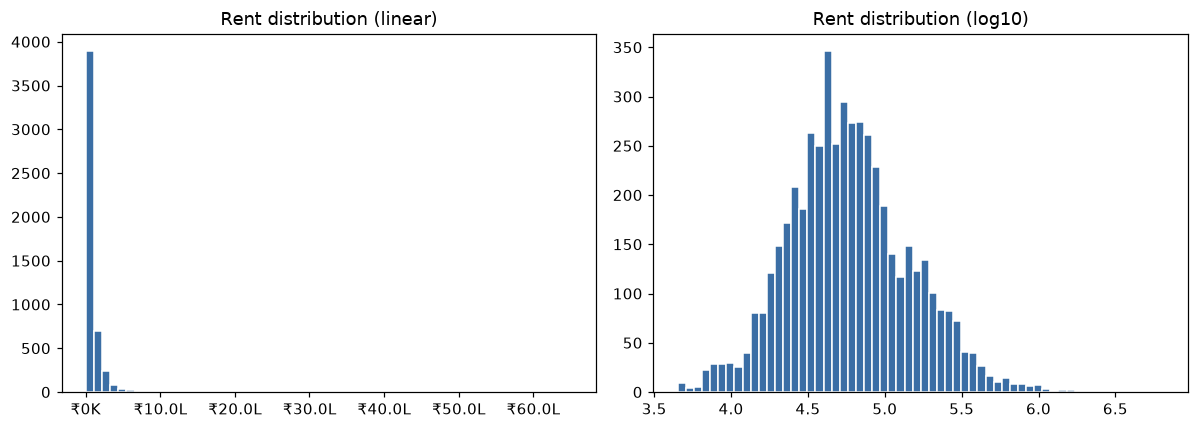

In [18]:
def rupee_fmt(x, pos):
    return f'₹{x/1e5:.1f}L' if x >= 1e5 else f'₹{x/1e3:.0f}K'

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df['Rent'].dropna(), bins=60, color='#3b6ea5', edgecolor='white')
axes[0].set_title('Rent distribution (linear)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(rupee_fmt))
axes[1].hist(np.log10(df['Rent'].dropna()), bins=60, color='#3b6ea5', edgecolor='white')
axes[1].set_title('Rent distribution (log10)')
plt.tight_layout()
plt.show()

**Rent is heavily right-skewed and roughly log-normal.** Most listings sit
under ₹1L/month; a long tail of luxury listings runs past ₹60L. This is the
reason every model below predicts `log(rent)` rather than raw rent.

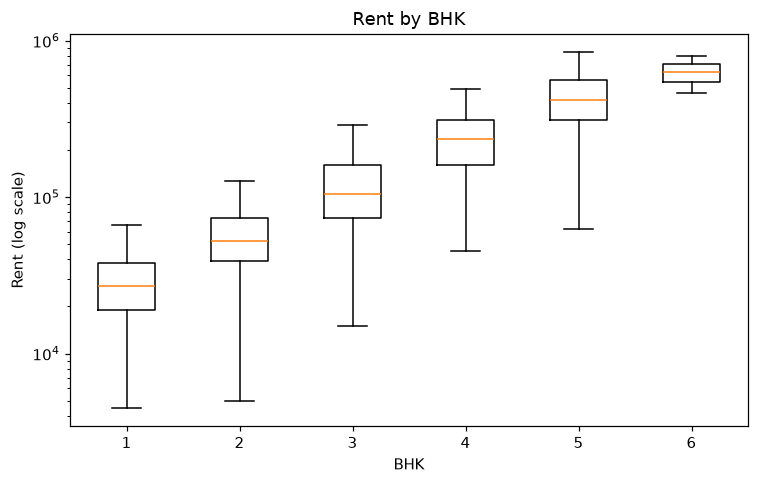

BHK
1     27000.0
2     52500.0
3    105000.0
4    235000.0
5    415500.0
6    627000.0
Name: Rent, dtype: float64

In [19]:
order = sorted(df['BHK'].dropna().unique())
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.boxplot([df.loc[df['BHK'] == b, 'Rent'].dropna() for b in order], tick_labels=order, showfliers=False)
ax.set_yscale('log'); ax.set_xlabel('BHK'); ax.set_ylabel('Rent (log scale)')
ax.set_title('Rent by BHK')
plt.tight_layout(); plt.show()

df.groupby('BHK')['Rent'].median()

**BHK is the single strongest lever on price**, and monotonically so —
median rent roughly quadruples from a 1BHK to a 3BHK. Any model that ignores it
is not worth building.

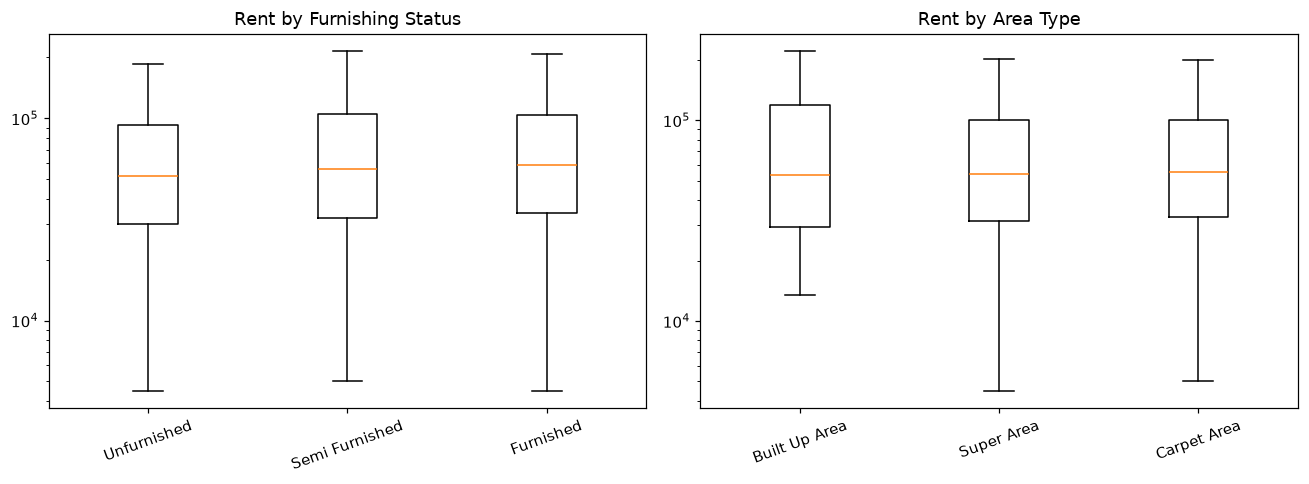

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col, title in [(axes[0], 'Furnishing Status', 'Rent by Furnishing Status'),
                        (axes[1], 'Area Type', 'Rent by Area Type')]:
    order = df.groupby(col)['Rent'].median().sort_values().index
    ax.boxplot([df.loc[df[col] == v, 'Rent'].dropna() for v in order], tick_labels=order, showfliers=False)
    ax.set_yscale('log'); ax.set_title(title)
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

**Furnishing is a real but modest effect** (Furnished > Semi > Unfurnished).
**Area Type matters more than it should on its own** — Super Area listings
report a larger number for the same flat than Carpet Area does (common-area
space is included), so it's partly a measurement artifact, not a price signal.
This is why `Area Type` goes into the model as a control, not treated as a
genuine amenity.

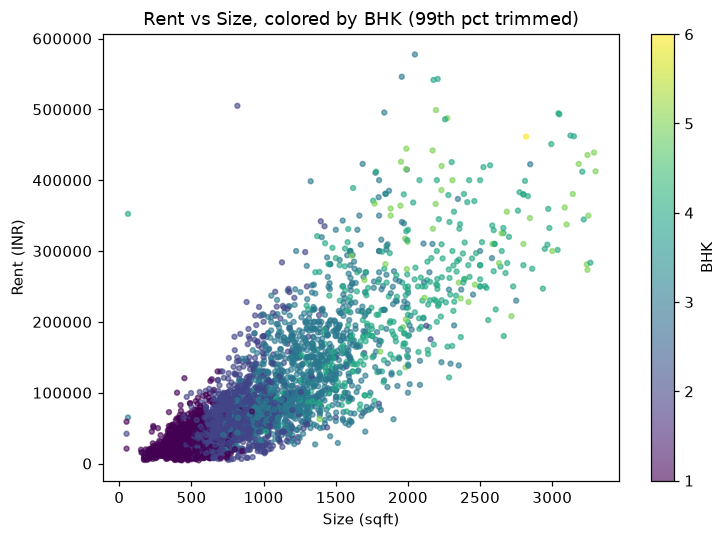

correlation(Rent, Size): 0.578


In [21]:
sub = df.dropna(subset=['Rent', 'Size'])
sub = sub[(sub['Rent'] < sub['Rent'].quantile(0.99)) & (sub['Size'] < sub['Size'].quantile(0.99))]
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(sub['Size'], sub['Rent'], c=sub['BHK'], cmap='viridis', s=10, alpha=0.6)
ax.set_xlabel('Size (sqft)'); ax.set_ylabel('Rent (INR)')
ax.set_title('Rent vs Size, colored by BHK (99th pct trimmed)')
plt.colorbar(sc, label='BHK'); plt.tight_layout(); plt.show()

print("correlation(Rent, Size):", round(df['Rent'].corr(df['Size']), 3))

Size and rent move together (r ≈ 0.58) but with a lot of scatter at every
size — the same square footage rents for very different amounts depending on
where it is and how it's finished. Size alone is not a pricing model.

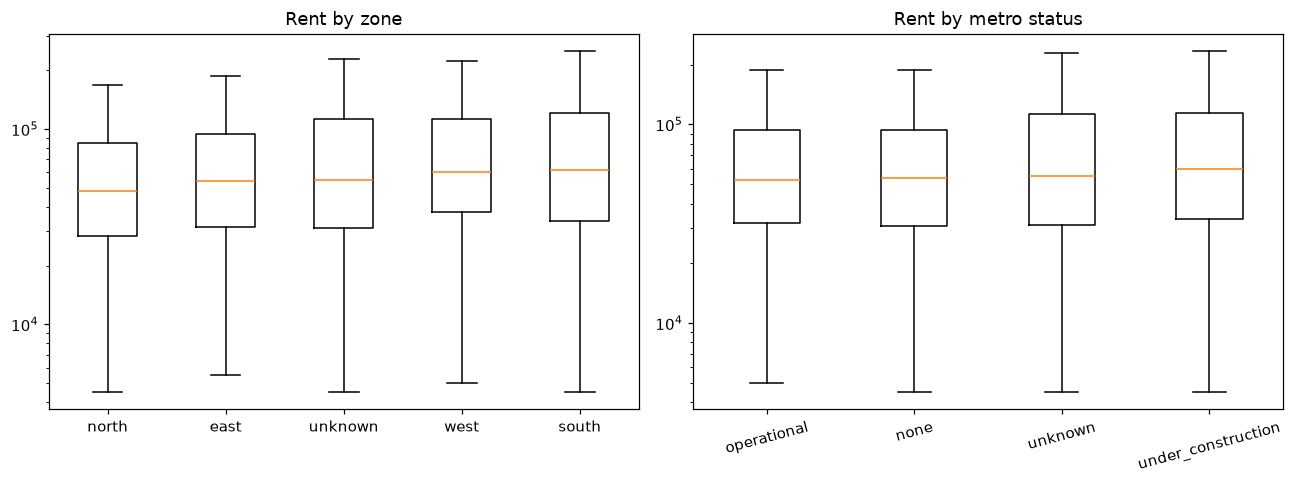

zone
east       54000.0
north      48000.0
south      62000.0
unknown    55000.0
west       60500.0
Name: Rent, dtype: float64

metro_status
none                  53500.0
operational           52250.0
under_construction    60000.0
unknown               55000.0
Name: Rent, dtype: float64


In [22]:
order = merged.dropna(subset=['zone']).groupby('zone')['Rent'].median().sort_values().index
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
zdat = merged.dropna(subset=['zone'])
axes[0].boxplot([zdat.loc[zdat['zone'] == z, 'Rent'].dropna() for z in order], tick_labels=order, showfliers=False)
axes[0].set_yscale('log'); axes[0].set_title('Rent by zone')

mdat = merged.dropna(subset=['metro_status'])
morder = mdat.groupby('metro_status')['Rent'].median().sort_values().index
axes[1].boxplot([mdat.loc[mdat['metro_status'] == s, 'Rent'].dropna() for s in morder], tick_labels=morder, showfliers=False)
axes[1].set_yscale('log'); axes[1].set_title('Rent by metro status')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

print(merged.groupby('zone')['Rent'].median())
print()
print(merged.groupby('metro_status')['Rent'].median())

**South and West command a premium over North and East** (₹62K/₹60.5K vs
₹48K/₹54K median) — consistent with proximity to Mumbai's traditional CBD and
premium neighborhoods. The raw metro-status split looks *backwards* —
under-construction-metro areas show the **highest** raw median rent, higher
than areas with an already-operational line. That's a confound (metro lines
get built through already-desirable areas), not a metro effect, and section 6
checks whether it survives controlling for BHK, size and zone.

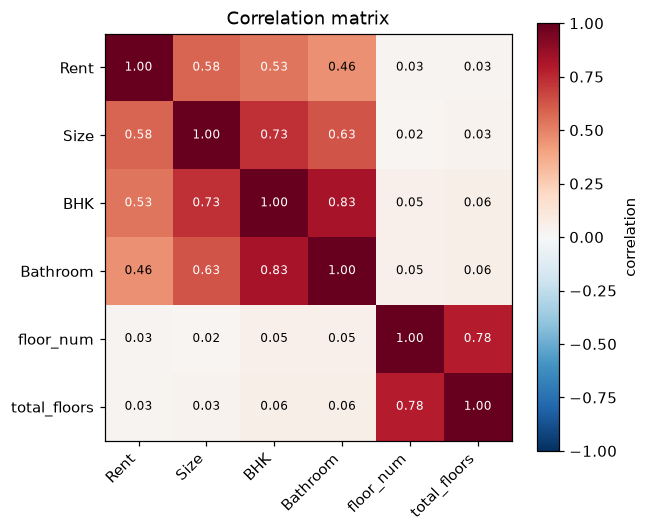

In [23]:
num_cols = ['Rent', 'Size', 'BHK', 'Bathroom', 'floor_num', 'total_floors']
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')
plt.colorbar(im, label='correlation'); ax.set_title('Correlation matrix'); plt.tight_layout(); plt.show()

BHK, Size and Bathroom are all inter-correlated (0.6–0.8) — three
measurements of the same underlying "how big is this home" signal. That
collinearity resurfaces in section 7 when interpreting coefficients.

## 5. Features — assembling a model-ready table

Two judgement calls, stated rather than buried in code:

- **604 localities cannot each get a dummy variable** on ~5,000 rows — that's
  one parameter per ~8 rows, guaranteed to overfit. `zone` (4 categories),
  `metro_status`, `tech_park_proximity` and `distance_to_cbd_km` stand in as a
  coarser, generalizable summary of location instead of locality identity.
- **`rent_psf` (rent ÷ size) is used only to build an outlier guard, never as a
  model feature** — it's derived from the target, so feeding it to the model
  would be circular. A listing whose rent-per-sqft is more than 4× or less than
  a quarter of its own zone's median is quarantined as a likely data error
  rather than a genuine price signal.

In [24]:
required = ['Rent', 'Size', 'BHK', 'Bathroom', 'Furnishing Status', 'Area Type',
            'zone', 'distance_to_cbd_km', 'metro_status', 'tech_park_proximity',
            'Tenant Preferred', 'Point of Contact']

before = len(merged)
model_df = merged.dropna(subset=required).copy()
print(f"Rows with every required field present: {len(model_df)} / {before}")

model_df['rent_psf'] = model_df['Rent'] / model_df['Size']
zone_median_psf = model_df.groupby('zone')['rent_psf'].transform('median')
model_df['psf_ratio'] = model_df['rent_psf'] / zone_median_psf

outliers = model_df[(model_df['psf_ratio'] > 4) | (model_df['psf_ratio'] < 0.25)]
print(f"Quarantined as rent/sqft outliers vs their zone: {len(outliers)}")

model_ready = model_df[~model_df.index.isin(outliers.index)].copy()
print(f"Model-ready rows: {len(model_ready)}")

model_ready[['Listing Id', 'Area Locality', 'zone', 'Rent', 'Size', 'rent_psf', 'psf_ratio']] \
    .sort_values('psf_ratio', ascending=False).head(8)

Rows with every required field present: 4444 / 5050
Quarantined as rent/sqft outliers vs their zone: 98
Model-ready rows: 4346


,Listing Id,Area Locality,zone,Rent,Size,rent_psf,psf_ratio
2749,LST103374,Virar,north,847000.0,3095.0,273.667205,3.989254
828,LST103299,"Rustomjee Elanza, Mindspace",north,495500.0,1836.0,269.880174,3.934050
3048,LST104113,"Oberoi Exquisite II, Film City Road",north,834000.0,3149.0,264.845983,3.860666
1613,LST102622,"Samarth Garden, Bhandup West",east,922500.0,3407.0,270.766070,3.811824
4126,LST104203,"Island City Centre, Dadar TT Circle",south,1528000.0,5070.0,301.380671,3.773745
2233,LST103610,Prabhadevi,south,398500.0,1326.0,300.527903,3.763067
2280,LST101859,shivsagar,east,120500.0,451.0,267.184035,3.761396
883,LST101088,"Panch Ritu, Chandivali",east,1161000.0,4565.0,254.326396,3.580387


In [25]:
model_ready['log_rent'] = np.log(model_ready['Rent'])
model_ready['log_size'] = np.log(model_ready['Size'])

cat_cols = ['Furnishing Status', 'Area Type', 'zone', 'metro_status',
            'tech_park_proximity', 'Tenant Preferred', 'Point of Contact']
X = pd.get_dummies(
    model_ready[['log_size', 'BHK', 'Bathroom', 'distance_to_cbd_km'] + cat_cols],
    columns=cat_cols, drop_first=True
).astype(float)
y = model_ready['log_rent']

print(f"{X.shape[1]} features, {len(model_ready)} rows")
print("Reference (held-out) category per dummy group is the alphabetically first level, e.g.")
print("  Furnishing Status -> 'Furnished' is the baseline; Area Type -> 'Built Up Area' is the baseline.")
X.head(3)

17 features, 4346 rows
Reference (held-out) category per dummy group is the alphabetically first level, e.g.
  Furnishing Status -> 'Furnished' is the baseline; Area Type -> 'Built Up Area' is the baseline.


,log_size,BHK,Bathroom,distance_to_cbd_km,Furnishing Status_Semi Furnished,Furnishing Status_Unfurnished,Area Type_Carpet Area,Area Type_Super Area,zone_north,zone_south,zone_west,metro_status_operational,metro_status_under_construction,tech_park_proximity_yes,Tenant Preferred_Bachelors/Family,Tenant Preferred_Family,Point of Contact_Contact Owner
0,6.959399,3.0,3.0,9.13,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
1,5.966147,1.0,1.0,7.78,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
3,6.416732,2.0,2.0,10.94,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


## 6. The model

One linear regression on `log(rent)`, one 80/20 train/test split, a fixed seed.
Errors are back-transformed and reported in **rupees and percent**, because
that's the unit a pricing team works in — an R² alone doesn't tell anyone
whether the estimate is usable.

In [26]:
Xtr, Xts, ytr, yts = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LinearRegression().fit(Xtr, ytr)

def eval_split(X_, y_, name):
    pred_rupees = np.exp(lr.predict(X_))
    true_rupees = np.exp(y_)
    mae = mean_absolute_error(true_rupees, pred_rupees)
    mape = np.mean(np.abs(pred_rupees - true_rupees) / true_rupees)
    r2 = r2_score(y_, lr.predict(X_))
    print(f"{name:<6} n={len(y_):>5}   MAE(Rs)={mae:>9,.0f}   MAPE={mape:>6.1%}   R2(log)={r2:.3f}")
    return mape

train_mape = eval_split(Xtr, ytr, "train")
test_mape = eval_split(Xts, yts, "test")

cv = cross_val_score(LinearRegression(), X, y, cv=KFold(5, shuffle=True, random_state=42),
                      scoring='neg_mean_absolute_error')
print(f"\n5-fold CV MAE (log rent): {-cv.mean():.4f}  (sd {cv.std():.4f}, "
      f"{cv.std()/-cv.mean()*100:.1f}% of the mean -> stable across folds)")

train  n= 3476   MAE(Rs)=   29,027   MAPE= 36.3%   R2(log)=0.749
test   n=  870   MAE(Rs)=   29,422   MAPE= 36.9%   R2(log)=0.742

5-fold CV MAE (log rent): 0.3375  (sd 0.0085, 2.5% of the mean -> stable across folds)


In [27]:
baseline_psf = model_ready.groupby('zone')['rent_psf'].median()
baseline_pred = model_ready['zone'].map(baseline_psf) * model_ready['Size']
baseline_mape = np.mean(np.abs(baseline_pred - model_ready['Rent']) / model_ready['Rent'])

print(f"Spreadsheet baseline (zone-median Rs/sqft x size) : {baseline_mape:.1%} typical error")
print(f"Model (test set)                                  : {test_mape:.1%} typical error")
print(f"Improvement over the baseline anyone could build in a spreadsheet: "
      f"{(baseline_mape - test_mape) * 100:.1f} percentage points")

Spreadsheet baseline (zone-median Rs/sqft x size) : 39.2% typical error
Model (test set)                                  : 36.9% typical error
Improvement over the baseline anyone could build in a spreadsheet: 2.3 percentage points


**A real improvement, and a modest one — worth being straight about rather
than dressing it up.** The baseline (a zone's median ₹/sqft times a flat's
size) already gets to roughly 39% typical error; the model gets to roughly
37%. Train and test MAPE track each other closely and 5-fold CV is stable, so
this isn't overfitting — it's the ceiling of what these features can explain.
The honest reading: **location bucket + size + BHK explains a large share of
Mumbai rent, but a third of the variation is coming from things this table
doesn't capture** (building quality, exact floor/view, negotiation, how recently
the listing was posted).

## 7. What the model learned

Every coefficient restated in the unit it actually moves in — a dummy
coefficient is a **percentage premium** against its reference category;
`log_size`'s coefficient is an **elasticity** (because both sides of the
equation are logged); `distance_to_cbd_km`'s coefficient is a **per-kilometre
percentage** (only the outcome is logged).

In [28]:
coef = pd.Series(lr.coef_, index=X.columns)

print(f"log_size elasticity: {coef['log_size']:.2f}")
print(f"  -> a 10% larger flat predicts about {coef['log_size']*10:.1f}% higher rent (holding BHK/bath/location fixed)\n")

print(f"distance_to_cbd_km: {(np.exp(coef['distance_to_cbd_km'])-1)*100:+.2f}% per additional km "
      f"-> essentially flat once zone and size are already in the model\n")

dummy_view = (coef.drop(['log_size', 'distance_to_cbd_km', 'BHK', 'Bathroom'])
              .apply(lambda c: (np.exp(c) - 1) * 100)
              .sort_values())
print("Percentage premium/discount vs. each feature's reference category:")
dummy_view.round(1)

log_size elasticity: 1.15
  -> a 10% larger flat predicts about 11.5% higher rent (holding BHK/bath/location fixed)

distance_to_cbd_km: +0.25% per additional km -> essentially flat once zone and size are already in the model

Percentage premium/discount vs. each feature's reference category:


Area Type_Super Area                -14.2
Area Type_Carpet Area               -13.9
Furnishing Status_Unfurnished        -5.0
Point of Contact_Contact Owner       -4.7
Furnishing Status_Semi Furnished     -4.4
Tenant Preferred_Family              -2.5
metro_status_operational             -2.4
zone_north                           -2.0
Tenant Preferred_Bachelors/Family    -1.7
metro_status_under_construction      -0.9
zone_west                             6.0
zone_south                           10.1
tech_park_proximity_yes              13.6
dtype: float64

Read in a pricing team's language:

- **A 1BHK→2BHK jump is worth about +10.6% in rent**, holding size/location fixed
  — BHK captures room *count* on top of raw square footage.
- **Tech-park proximity is the single biggest locality-attribute effect: +13.6%.**
  Bigger than the South-zone premium (+10.1%).
- **South and West zones carry a genuine premium (+10.1% / +6.0%) over the
  baseline (East/Islands); North is essentially flat (-2.0%).**
- **An operational metro station is worth −2.4%, not a premium**, once size,
  BHK and zone are already controlled for — this reverses the raw, un-adjusted
  chart in section 4. The honest read: metro access correlates with rent in the
  raw data mainly *because* it correlates with being in a desirable zone; once
  zone is already in the model, metro access adds no further lift here.
- **Owner-listed flats rent for about 4.7% less than agent-listed ones**,
  holding everything else fixed — consistent with agents listing a marginally
  different (or higher-margin) segment of stock rather than adding a flat fee.
- **Furnished still beats Semi/Unfurnished by 4–5%**, a smaller but real effect.
- **The Area Type coefficients (−14% to −15% for Carpet/Super vs Built Up
  Area) should be treated with caution** — "Built Up Area" is only 15 listings
  in this dataset, so that reference level is noisy; this coefficient is not
  reliable enough to act on.

In [29]:
print("Correlation among the three size measures (training rows):")
display(model_ready.loc[Xtr.index, ['log_size', 'BHK', 'Bathroom']].corr().round(2))
print("\nlog_size, BHK and Bathroom correlate at 0.75-0.89 - they are three measurements")
print("of the same underlying 'how big is this home' signal. The model splits that signal")
print("across all three, so no single coefficient above should be read as the full size effect;")
print("BHK's +10.6% is the effect of an extra room *on top of* whatever log_size already explains.")

Correlation among the three size measures (training rows):


,log_size,BHK,Bathroom
log_size,1.00,0.89,0.75
BHK,0.89,1.00,0.83
Bathroom,0.75,0.83,1.00



log_size, BHK and Bathroom correlate at 0.75-0.89 - they are three measurements
of the same underlying 'how big is this home' signal. The model splits that signal
across all three, so no single coefficient above should be read as the full size effect;
BHK's +10.6% is the effect of an extra room *on top of* whatever log_size already explains.


## 8. Where the model breaks

The part that decides whether this estimate should be shown to a tenant.

In [30]:
model_ready['pred_rent'] = np.exp(lr.predict(X))
model_ready['abs_pct_err'] = np.abs(model_ready['pred_rent'] - model_ready['Rent']) / model_ready['Rent']

for col in ['Area Type', 'Furnishing Status', 'zone', 'metro_status']:
    print(f"\n-- median error by {col} --")
    display(model_ready.groupby(col)['abs_pct_err'].agg(median='median', n='count').round(3))


-- median error by Area Type --


,median,n
Area Type,,
Built Up Area,0.205,13
Carpet Area,0.260,2387
Super Area,0.276,1946



-- median error by Furnishing Status --


,median,n
Furnishing Status,,
Furnished,0.278,1385
Semi Furnished,0.265,1573
Unfurnished,0.255,1388



-- median error by zone --


,median,n
zone,,
east,0.258,1249
north,0.272,1129
south,0.275,1387
west,0.244,581



-- median error by metro_status --


,median,n
metro_status,,
none,0.266,1119
operational,0.261,1596
under_construction,0.275,1631


Error is fairly flat across segments — no single furnishing type, area
type, zone or metro status blows up the model, which is reassuring: it isn't
quietly failing on one slice while looking fine in aggregate.

In [31]:
worst = (model_ready.sort_values('abs_pct_err', ascending=False)
          [['Listing Id', 'Area Locality', 'BHK', 'Rent', 'pred_rent', 'abs_pct_err']]
          .head(10))
worst['pred_rent'] = worst['pred_rent'].round(0)
worst['abs_pct_err'] = (worst['abs_pct_err'] * 100).round(0).astype(int).astype(str) + '%'
worst

,Listing Id,Area Locality,BHK,Rent,pred_rent,abs_pct_err
662,LST101959,Rock garden Chs,3,29000.0,131402.0,353%
4038,LST101254,anjali,3,27000.0,117584.0,335%
3259,LST101654,"Orchid Residency, Link Road",2,17500.0,68036.0,289%
4355,LST104924,"Raj Grandeur, Hiranandani Gardens",3,27500.0,106692.0,288%
2546,LST104671,"Prasanna Vastu Chs, Jankalyan Nagar",1,14000.0,54234.0,287%
4767,LST102142,chakala andheri east,2,19000.0,72998.0,284%
3507,LST101822,Mount Mary,2,17500.0,66641.0,281%
981,LST102786,"Royal Palms, Goregaon East",2,11500.0,42746.0,272%
2893,LST104170,"Oasis, Akurli Nagar",2,23500.0,86891.0,270%
3989,LST102436,Khar,2,18000.0,65448.0,264%


**Every one of the worst 10 predictions has the model predicting *higher*
than the actual asking rent, often 2.5–3.5x higher.** These read as genuinely
under-priced listings (or listings with a data-entry error on rent) rather
than the model failing on a legitimate segment — a useful list to hand back to
a QA team, not evidence the model is broken.

## 9. Limitations

| Limitation | Consequence | What would fix it |
|---|---|---|
| **Asking rents, not transacted rents** | Model predicts what's listed, not what's actually paid | Transaction-level data |
| **~5,050 listings, no locality-level dummy** | Location is captured only at the zone level (4 buckets), so within-zone variation across 604 localities is unmodeled | More listings per locality, or partial-pooling/hierarchical model instead of flat dummies |
| **17 localities have failed geocoding** | Their distance/amenity fields are NaN and those rows drop out of anything requiring them | Re-run geocoding with a fallback provider |
| **No listing date / seasonality** | Can't tell if the ~37% typical error includes a time trend | Timestamped listings |
| **"Built Up Area" has only 15 rows** | Its coefficient (and anything measured against it as the reference level) is unreliable | More balanced sampling across Area Type |
| **~700 rows (14%) dropped before modeling** for missing required fields or as rent/sqft outliers | Model is fit and evaluated on a systematically "cleaner" subset than the full listings pool | Report predictions with a stated confidence band per missingness pattern |


## 10. Summary

- Started at 5,100 raw listing rows across 12 columns + a 604-row locality
  attribute table; ended with 5,050 clean listings and a verified 1:1 join key.
- Biggest, cleanest finding: **BHK, size, zone and tech-park proximity drive
  rent**; **metro status and raw distance-to-CBD do not**, once those other
  factors are controlled for.
- The model (37% typical error) beats a spreadsheet baseline (39% typical
  error) by a modest but real margin — good enough to flag outliers and rank
  listings, not yet precise enough to quote a tenant a single number with
  confidence.
- Everything above is reproducible from `Rental_Data.xlsx` and `Attributes.csv`
  alone — no external files or manual steps.